# First look at the research rows

This notebook looks only at bars and funding rates before 2026-06-01 and at `results/audit/`, and it fits no model.
Rerun it with `uv run --group notebook jupyter nbconvert --to notebook --execute --inplace notebooks/exploration.ipynb`.

## 1. Coverage and liquidity

The grid runs from 2025-05-30 10:30 to 2026-05-31 23:55 UTC, with 105,570 five-minute rows for each of the eight assets.
Every asset misses the same three bars, 2025-08-29 06:20, 06:25 and 06:30 UTC, and no other bar.
They are a trading halt that Binance wrote as flat bars with zero trades, and the build sets such bars to missing.
Median value traded per day runs from 70M USDT for TRX to 804M USDT for DOGE, against 13,200M for BTC.

In [1]:
%matplotlib inline
import sys

import matplotlib as mpl
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, StrMethodFormatter
from scipy import stats

sys.path.append("..")

from src import plots
from src.config import DATA_DIR, GRID_START, PAIRS, RESEARCH_END, RESULTS_DIR, TARGETS
from src.experiments import phase1
from src.experiments.common import in_crash, utc

mpl.rcParams.update(plots.STYLE)
END = utc(RESEARCH_END)
COINS = list(TARGETS)
COINS_AND_BTC = [*COINS, "btc"]
MINUTE_FORMAT = "%Y-%m-%d %H:%M"

bars = pd.read_parquet(DATA_DIR / "bars.parquet", filters=[("open_time", "<", END)])
funding = pd.read_parquet(DATA_DIR / "funding.parquet", filters=[("open_time", "<", END)])
assert bars.index.max() < END and funding.index.max() < END


def field(name: str) -> pd.DataFrame:
    return bars[[f"{asset}_{name}" for asset in PAIRS]].set_axis(list(PAIRS), axis=1)


close = field("close")
returns = np.log(close).diff()
crash = in_crash(returns.index)

gaps = close.index[close.isna().any(axis=1)]
zero_trade = pd.read_csv(RESULTS_DIR / "audit" / "bars.csv").groupby("asset")["zero_trade"].sum()
value_traded = field("quote_volume").resample("1D").sum().median() / 1e6
first, last = (f"{moment:{MINUTE_FORMAT}}" for moment in close.index[[0, -1]])
print(f"{first} to {last} UTC, {len(close):,} rows")
print("missing on any asset:", ", ".join(f"{t:{MINUTE_FORMAT}}" for t in gaps))
pd.DataFrame(
    {
        "bars": close.count(),
        "missing": close.isna().sum(),
        "zero-trade bars in the archive": zero_trade,
        "median value traded per day, M USDT": value_traded,
    },
    index=list(PAIRS),
).round().astype(int).rename(index=plots.display_name)

2025-05-30 10:30 to 2026-05-31 23:55 UTC, 105,570 rows
missing on any asset: 2025-08-29 06:20, 2025-08-29 06:25, 2025-08-29 06:30


,bars,missing,zero-trade bars in the archive,"median value traded per day, M USDT"
HYPE,105567,3,3,357
TRX,105567,3,3,70
DOGE,105567,3,3,804
UNI,105567,3,3,113
AAVE,105567,3,3,138
BTC,105567,3,3,13200
ETH,105567,3,3,13312
SOL,105567,3,3,2937


## 2. Fat tails

With 2025-10-10 and 2025-10-11 included, DOGE, UNI and AAVE have an excess kurtosis above 8,000.
The largest 0.1 percent of their bars, about 106 bars each, carry 43 to 52 percent of their variance.
Without the two days the excess kurtosis is 8 to 174 and the share is 6 to 16 percent.
A normal distribution would give 0 and 1.3 percent.
UNI's 174 is mostly one bar, 2026-02-11 14:00 UTC, with a log return of 0.18, and without it UNI is at 30.

In [2]:
def top_share(r: pd.Series, share: float = 0.001) -> float:
    squares = r.dropna().pow(2).sort_values(ascending=False)
    return squares.iloc[: round(share * len(squares))].sum() / squares.sum()


# share of E[Z^2] above the 99.9th percentile of |Z| for a standard normal Z
cut = stats.norm.isf(0.0005)
normal_share = 2 * (cut * stats.norm.pdf(cut) + stats.norm.sf(cut))
tails = pd.DataFrame(
    {
        "excess kurtosis": returns[COINS_AND_BTC].kurt(),
        "excess kurtosis, no Oct 10-11": returns.loc[~crash, COINS_AND_BTC].kurt(),
        "top 0.1% of bars, % of variance": returns[COINS_AND_BTC].apply(top_share) * 100,
        "same, no Oct 10-11": returns.loc[~crash, COINS_AND_BTC].apply(top_share) * 100,
    }
)
tails.loc["normal distribution"] = [0, 0, normal_share * 100, normal_share * 100]
uni = returns.loc[~crash, "uni"]
largest = uni.abs().idxmax()
moment = f"{largest:{MINUTE_FORMAT}}"
print(f"UNI's largest bar outside Oct 10-11: {moment}, log return {uni[largest]:.3f}")
print(f"UNI excess kurtosis without Oct 10-11 and that bar: {uni.drop(largest).kurt():.1f}")
tails.round(1).rename(index=plots.display_name)

UNI's largest bar outside Oct 10-11: 2026-02-11 14:00, log return 0.184
UNI excess kurtosis without Oct 10-11 and that bar: 30.4


,excess kurtosis,"excess kurtosis, no Oct 10-11","top 0.1% of bars, % of variance","same, no Oct 10-11"
HYPE,223.7,8.2,13.9,6.0
TRX,293.3,66.9,18.3,13.2
DOGE,10496.9,33.4,47.9,11.2
UNI,8273.9,174.1,43.3,16.0
AAVE,12296.3,18.2,51.5,9.6
BTC,155.0,23.4,14.5,10.2
normal distribution,0.0,0.0,1.3,1.3


## 3. The 2025-10-10 crash

The fall started on the 20:50 bar, and every coin had its lowest close on the 21:15 bar.
Indexed to 100 at the 20:00 close, that close was 45 for AAVE, 46 for UNI, 48 for DOGE, 69 for HYPE and 91 for TRX, against 89 for BTC.
Inside the bars the lows went further, to 30 for UNI, 31 for AAVE and 36 for DOGE.
By 22:00 the coins were back at 71 to 96.
These bars sit in the first training window, so section 2 reports each tail statistic with and without the two days.

,lowest close,bar of the lowest close,lowest low,22:00 close
HYPE,69,21:15,49,93
TRX,91,21:15,90,96
DOGE,48,21:15,36,77
UNI,46,21:15,30,71
AAVE,45,21:15,31,81
BTC,89,21:15,87,97


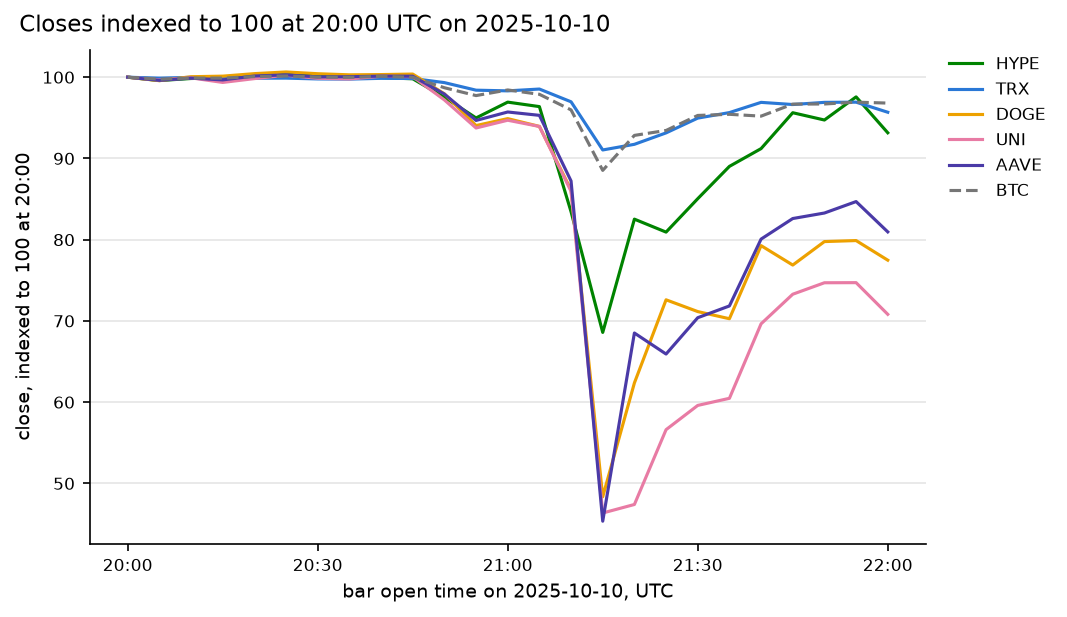

In [3]:
window = close.loc["2025-10-10 20:00":"2025-10-10 22:00", COINS_AND_BTC]
indexed = window / window.iloc[0] * 100
lows = field("low").loc[window.index, COINS_AND_BTC] / window.iloc[0] * 100

fig, ax = plots.single_plot("Closes indexed to 100 at 20:00 UTC on 2025-10-10")
plots.coin_lines(ax, indexed[COINS])
ax.plot(indexed.index, indexed["btc"], color=plots.GREY, linestyle="--", label="BTC")
plots.date_axis(ax)
ax.set_xlabel("bar open time on 2025-10-10, UTC")
ax.set_ylabel("close, indexed to 100 at 20:00")
plots.legend_beside(ax)
crash_bars = pd.DataFrame(
    {
        "lowest close": indexed.min().round().astype(int),
        "bar of the lowest close": indexed.idxmin().dt.strftime("%H:%M"),
        "lowest low": lows.min().round().astype(int),
        "22:00 close": indexed.iloc[-1].round().astype(int),
    }
)
display(crash_bars.rename(index=plots.display_name))
fig

## 4. Volatility by week and by hour

Volatility here is the standard deviation of 5-minute log returns, in bps.
The median week is 22 to 30 bps for HYPE, DOGE, UNI and AAVE and 8 bps for TRX.
The week from 2025-10-10 is the highest for every coin, at 88 bps for HYPE and 155 to 181 bps for DOGE, UNI and AAVE.
By hour of day, without the crash days, four coins peak in the 14:00 UTC hour and TRX in the 12:00 hour.
The busiest hour is 1.6 to 2.0 times as volatile as the quietest.

,"median week, bps","highest week, bps",highest week from,"busiest hour, UTC",busiest over quietest hour
HYPE,30.4,87.8,2025-10-10,14,1.56
TRX,7.6,20.1,2025-10-10,12,1.57
DOGE,22.4,154.6,2025-10-10,14,1.78
UNI,25.7,155.6,2025-10-10,14,2.05
AAVE,24.4,181.1,2025-10-10,14,1.67


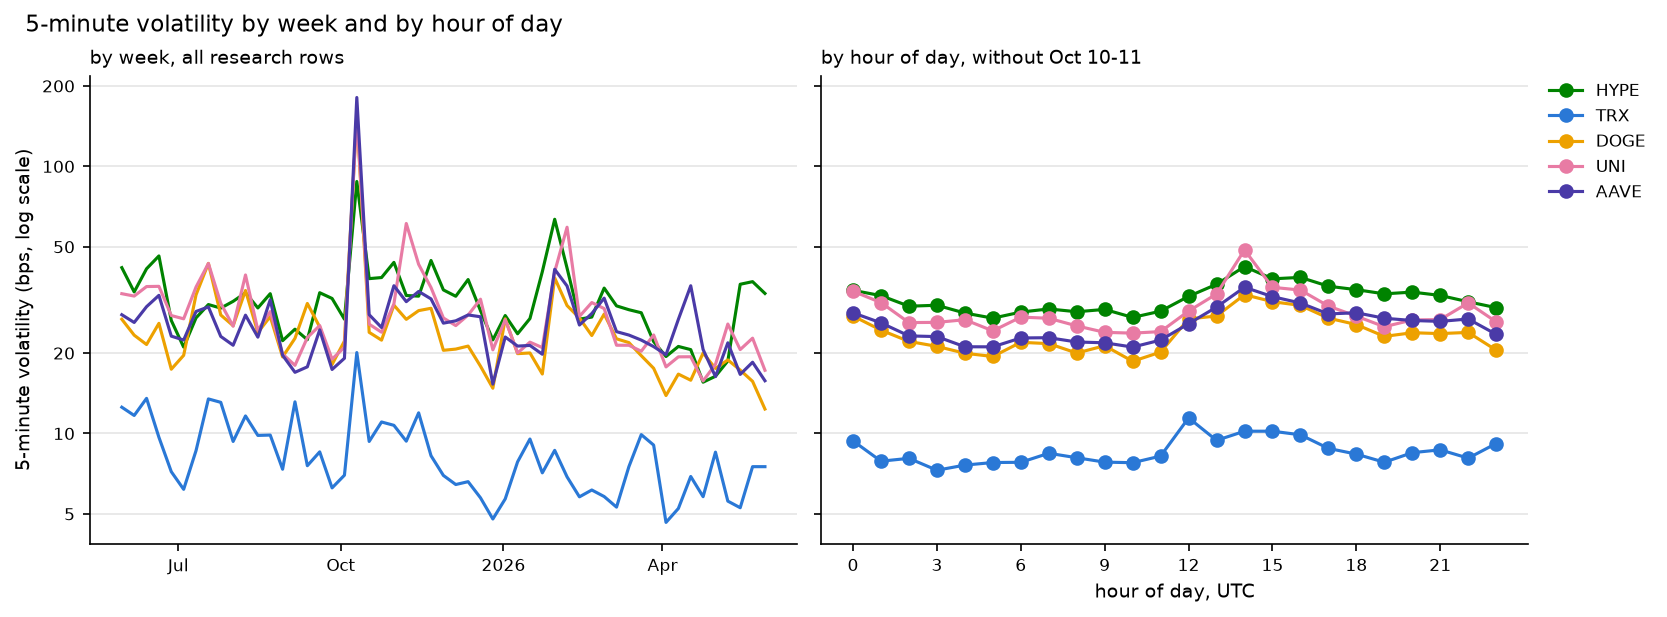

In [4]:
weekly = returns[COINS].resample("7D").std() * 1e4
calm = returns[~crash]
hourly = calm[COINS].groupby(calm.index.hour).std() * 1e4

title = "5-minute volatility by week and by hour of day"
fig, (by_week, by_hour) = plots.small_multiples(2, 2, (11, 4), title, sharey=True)
plots.coin_lines(by_week, weekly)
plots.date_axis(by_week)
by_week.set_title("by week, all research rows")
by_week.set_yscale("log")
by_week.yaxis.set_major_locator(LogLocator(subs=(1, 2, 5)))
by_week.yaxis.set_major_formatter(StrMethodFormatter("{x:g}"))
by_week.minorticks_off()
by_week.set_ylabel("5-minute volatility (bps, log scale)")
plots.coin_lines(by_hour, hourly, marker="o")
by_hour.set_xticks(range(0, 24, 3))
by_hour.set_xlabel("hour of day, UTC")
by_hour.set_title("by hour of day, without Oct 10-11")
plots.legend_beside(by_hour)
volatility = pd.DataFrame(
    {
        "median week, bps": weekly.median().round(1),
        "highest week, bps": weekly.max().round(1),
        "highest week from": weekly.idxmax().dt.strftime("%Y-%m-%d"),
        "busiest hour, UTC": hourly.idxmax(),
        "busiest over quietest hour": (hourly.max() / hourly.min()).round(2),
    }
)
display(volatility.rename(index=plots.display_name))
fig

## 5. Does BTC move before the coins?

BTC leads the coins by very little at 5-minute bars.
Without the crash days, the same-bar correlation with BTC is 0.39 for TRX to 0.74 for DOGE.
With BTC one bar ahead it is -0.001 to 0.011, so BTC's last bar explains at most about 0.01 percent of a coin's next-bar variance.
Every other lag from -6 to +6 bars stays within 0.022 of zero.
The shaded band is two standard errors of a zero correlation over about 105,000 bars, ignoring dependence.
The dips at -2 and +2 bars appear on both sides, so they say nothing about which series leads.
The audit's June to November 2025 window in `results/audit/lead_lag.csv` stays within 0.029 of zero.

,HYPE,TRX,DOGE,UNI,AAVE
same bar,0.565,0.387,0.740,0.651,0.712
BTC one bar ahead,-0.001,0.008,0.011,0.006,0.006


largest |correlation| at another lag: 0.022
same in the audit window, Jun to Nov 2025: 0.029


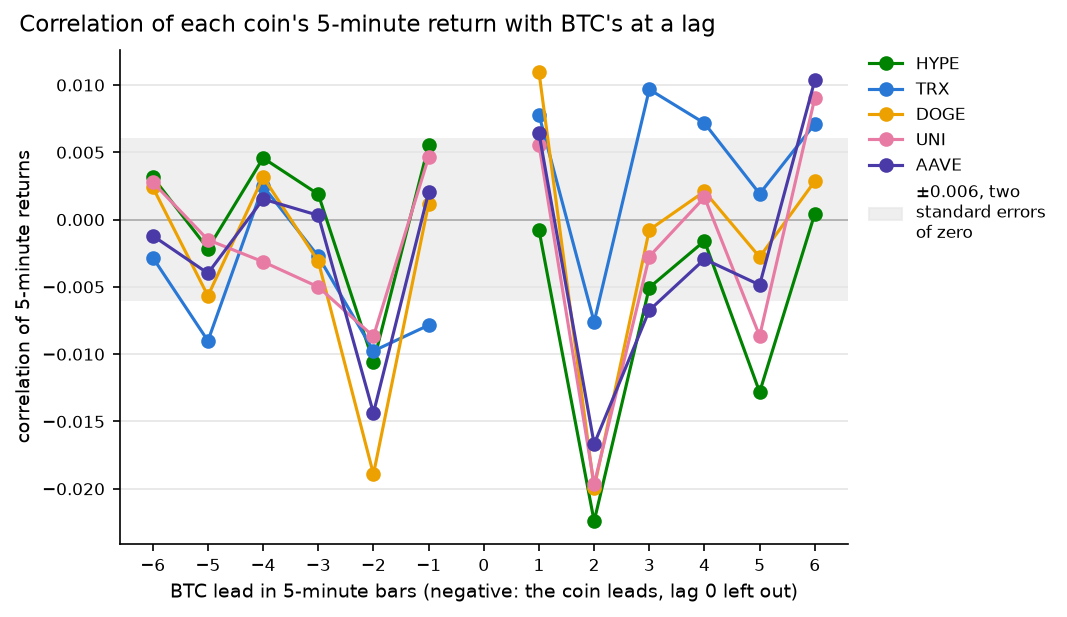

In [5]:
lead_lag_table = phase1.lead_lag_table(returns)
lags = lead_lag_table.set_index("btc_lead_bars")
audit_window = pd.read_csv(RESULTS_DIR / "audit" / "lead_lag.csv", index_col="btc_lead_bars")
band = 1.96 / np.sqrt(returns.loc[~crash, "btc"].count())

fig = plots.plot_lead_lag(lead_lag_table)
ax = fig.axes[0]
ax.axhspan(-band, band, color=plots.GRID, alpha=0.6, linewidth=0, zorder=0)
noise = Patch(color=plots.GRID, alpha=0.6, label=f"±{band:.3f}, two\nstandard errors\nof zero")
plots.legend_beside(ax, [*ax.get_legend_handles_labels()[0], noise])
nearest = lags.loc[[0, 1]].rename(index={0: "same bar", 1: "BTC one bar ahead"}).rename_axis(None)
display(nearest.round(3).rename(columns=plots.display_name))
other_lags = lags.drop(index=0).abs().max().max()
audit_lags = audit_window.drop(index=0).abs().max().max()
print(f"largest |correlation| at another lag: {other_lags:.3f}")
print(f"same in the audit window, Jun to Nov 2025: {audit_lags:.3f}")
fig

## 6. Funding

Funding settles every 4 hours on HYPE and every 8 hours on the other four.
HYPE sits at 0.5 bps, the base rate of 1 bps per 8 hours, in 61 percent of settlements.
The other four sit at their 1 bps base rate in 20 to 34 percent of settlements.
On average a long position paid 2.5 bps a day on HYPE and 0.9 to 1.4 bps a day on DOGE, UNI and AAVE.
On TRX it was paid 0.7 bps a day, and 46 percent of TRX settlements are negative.
The extremes for HYPE and TRX are the settlement after the crash, 2025-10-11 00:00 UTC, at +19.8 and -16.8 bps.
A taker round trip costs 10 bps, four times HYPE's average funding for a whole day.

,"at the base rate, %","negative, %","mean, bps per day","lowest, bps","highest, bps","2025-10-11 00:00, bps"
HYPE,61,15,2.49,-6.5,19.8,19.8
TRX,24,46,-0.69,-16.8,2.4,-16.8
DOGE,23,30,0.94,-2.6,4.5,4.5
UNI,34,21,1.37,-3.0,3.1,1.0
AAVE,20,24,1.05,-3.3,1.0,1.0


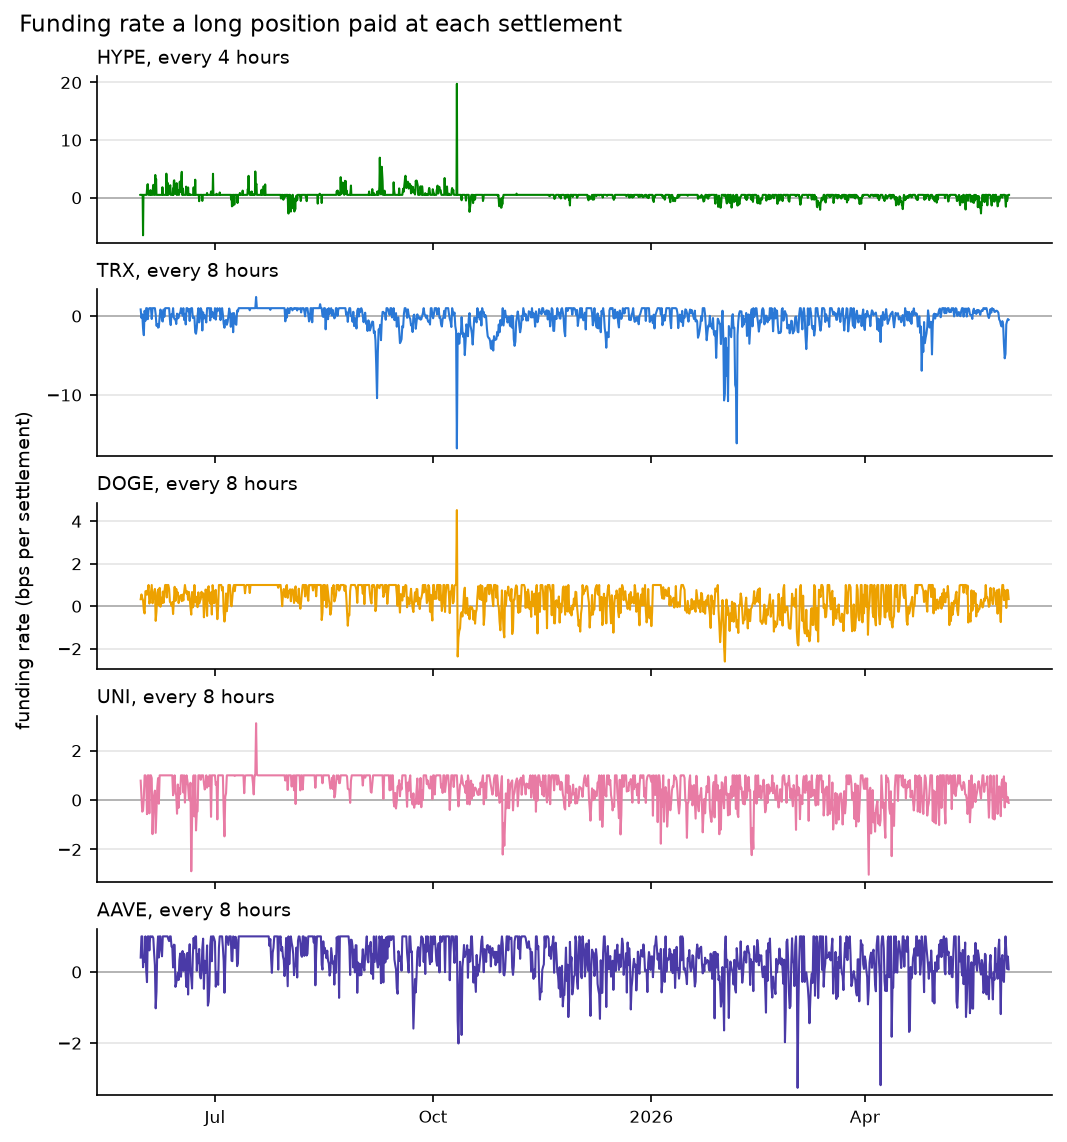

In [6]:
rates = funding.loc[GRID_START:] * 1e4
days = (END - utc(GRID_START)) / pd.Timedelta(days=1)
spacing = pd.Series({c: rates[c].dropna().index.diff().median() for c in COINS})
hours = spacing / pd.Timedelta(hours=1)

title = "Funding rate a long position paid at each settlement"
fig, axes = plots.small_multiples(len(COINS), 1, (7, 7.5), title, sharex=True)
for ax, coin in zip(axes, COINS, strict=True):
    settled = rates[coin].dropna()
    ax.plot(settled.index, settled, color=plots.COIN_COLOURS[coin], linewidth=1)
    plots.zero_line(ax)
    ax.set_title(f"{plots.display_name(coin)}, every {hours[coin]:.0f} hours")
plots.date_axis(axes[-1])
fig.supylabel("funding rate (bps per settlement)")
settlements = rates.count()
summary = pd.DataFrame(
    {
        "at the base rate, %": rates.round(6).eq(hours / 8).sum() / settlements * 100,
        "negative, %": (rates < 0).sum() / settlements * 100,
        "mean, bps per day": (rates.sum() / days).round(2),
        "lowest, bps": rates.min().round(1),
        "highest, bps": rates.max().round(1),
        "2025-10-11 00:00, bps": rates.loc[utc("2025-10-11")].round(1),
    }
)
percent = ["at the base rate, %", "negative, %"]
summary[percent] = summary[percent].round().astype(int)
display(summary.rename(index=plots.display_name))
fig

## 7. Daily correlation with BTC

Over 366 daily returns the correlation with BTC is 0.42 for TRX, 0.52 for HYPE, 0.65 for UNI, 0.73 for AAVE and 0.75 for DOGE.
DOGE, UNI and AAVE move as a block, with pairwise correlations of 0.70 to 0.76.
TRX follows the others least, at 0.28 to 0.46 with each of them.
DOGE and AAVE, a close pair in the paper at 0.84 from August to November 2025, are at 0.76 over the whole year.
Leaving out 2025-10-10 and 2025-10-11 lowers every correlation, by at most 0.03.

366 daily returns
leaving out Oct 10-11 lowers the correlations by 0.005 to 0.026


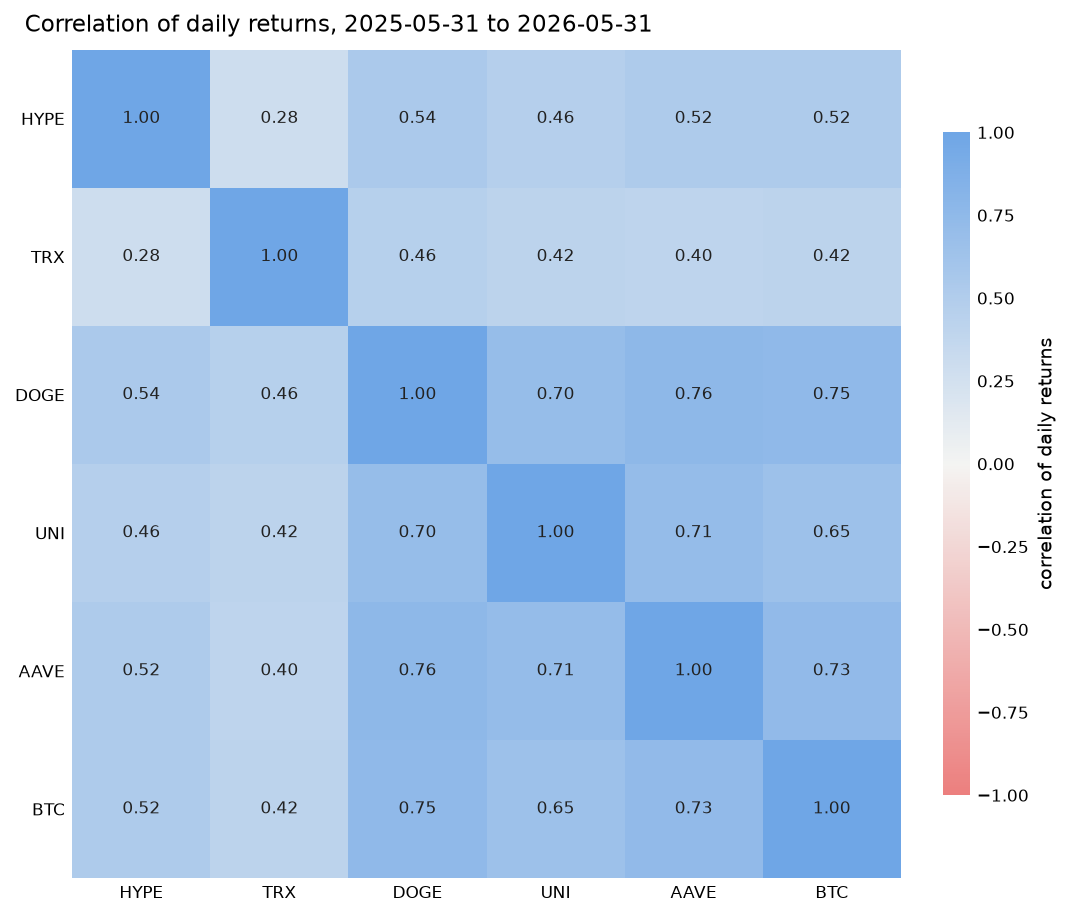

In [7]:
daily = close[COINS_AND_BTC].resample("1D").last().pct_change().dropna()
without_crash = daily[~in_crash(daily.index)]
pairs = np.triu_indices(len(COINS_AND_BTC), 1)
change = (daily.corr() - without_crash.corr()).to_numpy()[pairs]
print(f"{len(daily)} daily returns")
print(f"leaving out Oct 10-11 lowers the correlations by {change.min():.3f} to {change.max():.3f}")
plots.plot_correlation(
    daily.corr().rename_axis("asset").reset_index(),
    "Correlation of daily returns, 2025-05-31 to 2026-05-31",
    "correlation of daily returns",
)